In [19]:
%reset -f 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#Funciones auxiliares sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold #Split y cross Validation
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score #Metricas
from sklearn.utils import shuffle 


#Gradient Boosting
import lightgbm as lgb


# Configuramos el estilo de las visualizaciones
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#Funciones auxiliares sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold #Split y cross Validation
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score #Metricas
from sklearn.utils import shuffle 


#Gradient Boosting
import lightgbm as lgb


# Configuramos el estilo de las visualizaciones
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")


SEED = 42 #Semilla de procesos aleatorios (para poder replicar exactamente al volver a correr un modelo)



In [20]:
import os
print(f"Tu Python está mirando en: {os.getcwd()}")

Tu Python está mirando en: c:\Users\GWF-SerIA\Documents\GitHub\Labo_2_Grupo_15


In [21]:


# Carga de archivos tabulares con feature enginering
df_train = pd.read_csv('work/df_train_FE_split.csv')
df_test = pd.read_csv('work/df_test_FE_split.csv')

# 2. Salidas de la ResNet (Probabilidades/Softmax)
# Estas suelen tener columnas como: PetID, prob_0, prob_1, prob_2, prob_3, prob_4
df_prob_train = pd.read_csv('work/resnet_probabilities_train.csv')
df_prob_test = pd.read_csv('work/resnet_probabilities_test.csv')

In [22]:
# 1. Realizar el merge por PetID
# Usamos how='left' para mantener todas las filas del set tabular original
df_train_final = pd.merge(df_train, df_prob_train, on='PetID', how='left')
df_test_final = pd.merge(df_test, df_prob_test, on='PetID', how='left')

# 2. Verificar si hubo mascotas sin probabilidades (nulos)
nulos_prob = df_train_final[df_prob_train.columns.drop('PetID')].isna().sum()
if nulos_prob.any():
    print("Advertencia: Hay mascotas en train sin probabilidades de ResNet. Completando con 0 o promedio...")
    # Opción: Llenar con 0 o con una distribución uniforme (0.2 para cada clase en 5 clases)
    cols_prob = [c for c in df_prob_train.columns if c != 'PetID']
    df_train_final[cols_prob] = df_train_final[cols_prob].fillna(0)

# 3. Revisar las dimensiones finales
print(f"Dataset original: {df_train.shape}")
print(f"Dataset tras merge: {df_train_final.shape}")

# Mostrar las primeras filas para confirmar que las columnas prob_0...prob_4 estén ahí
display(df_train_final.head())

# 2. Verificar si hubo mascotas sin probabilidades (nulos)
nulos_prob = df_test_final[df_prob_test.columns.drop('PetID')].isna().sum()
if nulos_prob.any():
    print("Advertencia: Hay mascotas en test sin probabilidades de ResNet. Completando con 0 o promedio...")
    # Opción: Llenar con 0 o con una distribución uniforme (0.2 para cada clase en 5 clases)
    cols_prob = [c for c in df_prob_test.columns if c != 'PetID']
    df_test_final[cols_prob] = df_test_final[cols_prob].fillna(0)

# 3. Revisar las dimensiones finales
print(f"Dataset original: {df_test.shape}")
print(f"Dataset tras merge: {df_test_final.shape}")

# Mostrar las primeras filas para confirmar que las columnas prob_0...prob_4 estén ahí
display(df_test_final.head())


Advertencia: Hay mascotas en train sin probabilidades de ResNet. Completando con 0 o promedio...
Dataset original: (11994, 38)
Dataset tras merge: (11994, 43)


,Type,Age,Breed1,Gender,Color1,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,...,Size_x_Fur,Color_x_Fur,Num_Colors,Is_Mixed,AdoptionSpeed,resnet_prob_class_0,resnet_prob_class_1,resnet_prob_class_2,resnet_prob_class_3,resnet_prob_class_4
0,1,2,307,1,1,2,2,2,1,2,...,4,2,1,1,2,0.007917,0.199507,0.551587,0.154812,0.086176
1,1,12,307,2,2,1,1,1,1,1,...,1,2,1,1,3,0.004548,0.045195,0.162081,0.279971,0.508204
2,1,2,307,1,1,2,1,2,2,2,...,2,1,3,1,4,0.000085,0.029217,0.128326,0.150344,0.692028
3,1,2,307,1,3,2,2,1,1,2,...,4,6,1,1,1,0.047265,0.477291,0.245986,0.151476,0.077982
4,2,4,265,3,1,2,2,2,2,2,...,4,2,2,0,2,0.023851,0.323821,0.311343,0.127534,0.213450


Advertencia: Hay mascotas en test sin probabilidades de ResNet. Completando con 0 o promedio...
Dataset original: (2999, 38)
Dataset tras merge: (2999, 43)


,Type,Age,Breed1,Gender,Color1,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,...,Size_x_Fur,Color_x_Fur,Num_Colors,Is_Mixed,AdoptionSpeed,resnet_prob_class_0,resnet_prob_class_1,resnet_prob_class_2,resnet_prob_class_3,resnet_prob_class_4
0,1,1,307,2,1,2,2,2,2,2,...,4,2,1,1,4,0.020140,0.207721,0.313455,0.270560,0.188124
1,1,24,103,2,1,2,1,1,1,2,...,2,1,3,1,4,0.007805,0.091443,0.122789,0.201409,0.576553
2,1,2,307,2,2,2,1,1,1,2,...,2,2,2,1,4,0.003426,0.121601,0.184929,0.307666,0.382378
3,2,1,265,1,2,1,2,1,1,2,...,2,4,1,0,2,0.019532,0.505996,0.229732,0.116804,0.127936
4,2,9,266,2,2,2,1,2,2,2,...,2,2,3,1,4,0.014399,0.135383,0.225305,0.269691,0.355221


In [23]:
# 1. Lista de variables que DESEAMOS que sean categóricas
# (He quitado PetID, Name y RescuerID porque acordamos eliminarlas por ruido)
desired_categorical = [
    'Type', 'Breed1', 'Gender', 'Color1', 'Is_Mixed', 
    'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 
    'SizeCategory', 'MaturitySize', 'Description', 'Has_Name'
]

# 2. Convertir a 'category' de forma segura
for col in desired_categorical:
    # Verificamos si la columna existe en df_train_final antes de transformarla
    if col in df_train_final.columns:
        df_train_final[col] = df_train_final[col].astype('category')
        
    # Hacemos lo mismo para df_test_final
    if col in df_test_final.columns:
        df_test_final[col] = df_test_final[col].astype('category')
    else:
        # Esto te avisará si alguna columna de tu lista no está en el DataFrame
        continue 

print("✅ Conversión a categóricas finalizada sin errores.")

✅ Conversión a categóricas finalizada sin errores.


In [24]:
#Genero dataframes de train y test con sus respectivos targets
X_train = df_train_final.drop(columns=['AdoptionSpeed'])
y_train = df_train_final['AdoptionSpeed']

X_test = df_test_final.drop(columns=['AdoptionSpeed'])
y_test = df_test_final['AdoptionSpeed']

In [26]:
# 1. ELIMINAR IDENTIFICADORES
# Quitamos los IDs 
cols_to_drop = ['PetID']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [27]:
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================================
# 1. Preparación de Datasets (Uso de validación real)
# ============================================================================
# Es fundamental que valid_sets reciba datos que el modelo NO vio en el training
dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
dvalid = lgb.Dataset(X_test, label=y_test, reference=dtrain)

# ============================================================================
# 2. Parámetros y Entrenamiento
# ============================================================================
params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'verbosity': -1,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 7,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42
}

print("Entrenando modelo con Early Stopping...")
model = lgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
)

# ============================================================================
# 3. Importancia de Variables (Gain)
# ============================================================================
importance_type = 'gain' 

feature_importances = model.feature_importance(importance_type=importance_type)
feature_names = X_train.columns

# Crear DataFrame de importancia
df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances,
    'importance_pct': (feature_importances / feature_importances.sum() * 100).round(2) if feature_importances.sum() > 0 else 0
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Mostrar resultados
print("\n=== Top 60 Importancia de Features (Gain) ===")
print(df_importance.head(60))


Entrenando modelo con Early Stopping...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[185]	train's multi_error: 0.240454	valid's multi_error: 0.587863

=== Top 60 Importancia de Features (Gain) ===
                   feature    importance  importance_pct
0      resnet_prob_class_4  23164.844484           13.78
1      resnet_prob_class_1  18715.598402           11.14
2      resnet_prob_class_2  15017.216401            8.94
3      resnet_prob_class_3  14879.111222            8.85
4      resnet_prob_class_0  11475.643104            6.83
5         rescu_avg_photos  11105.783539            6.61
6   rescu_breed_experience   8024.431493            4.77
7           Age_x_PhotoAmt   5117.691640            3.05
8              Age_x_Salud   4818.235151            2.87
9           Breed_x_Color1   4652.917701            2.77
10          Photos_per_Pet   4406.075236            2.62
11           Age_per_Breed   4128.408611            2.46
12        

In [28]:
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score

# ==========================================================
# 1. CÁLCULO DE GAIN (TABLA 1)
# ==========================================================
print("Calculando importancia por Gain...")
df_gain = pd.DataFrame({
    'feature': X_train.columns,
    'gain': model.feature_importance(importance_type='gain')
})

# ==========================================================
# 2. CÁLCULO DE PERMUTATION IMPACT (TABLA 2)
# ==========================================================
print("\nIniciando auditoría de impacto en Test (Permutation)...")

def get_full_audit(model, X_test_audit, y):
    # Aseguramos que el orden de columnas sea idéntico al de entrenamiento
    features = X_train.columns.tolist()
    X_test_audit = X_test_audit[features].copy() # Copia profunda para seguridad
    
    # Predicción base (asegúrate de que y sea un array plano para evitar líos de dimensiones)
    y_true = np.array(y).flatten()
    y_pred_base = model.predict(X_test_audit)
    baseline_score = average_precision_score(y_true, y_pred_base)
    
    print(f"Baseline PR-AUC en Test: {baseline_score:.4f}")
    
    results = []
    
    for i, col in enumerate(features):
        # Guardamos el estado original
        original_col = X_test_audit[col].copy()
        
        # PERMUTACIÓN SEGURA (usando .sample para mantener todo el objeto Series intacto)
        # Esto mantiene el índice, las categorías y el tipo de dato perfectamente.
        X_test_audit[col] = X_test_audit[col].sample(frac=1, replace=False).values
        
        # Si era categórica, restauramos el tipo exacto para que LightGBM no se queje
        if original_col.dtype.name == 'category':
            X_test_audit[col] = X_test_audit[col].astype('category')
            X_test_audit[col] = X_test_audit[col].cat.set_categories(original_col.cat.categories)

        # Medición de impacto
        y_pred_shuffled = model.predict(X_test_audit)
        shuffled_score = average_precision_score(y_true, y_pred_shuffled)
        drop = baseline_score - shuffled_score
        
        results.append(drop)
        
        # RESTAURACIÓN
        X_test_audit[col] = original_col
        
        if (i+1) % 5 == 0 or i == 0:
            print(f"[{i+1}/{len(features)}] Auditada: {col} | Drop: {drop:.6f}")
            
    return pd.DataFrame({'feature': features, 'test_impact': results})

# Ejecutamos la auditoría sobre una copia limpia
df_audit = get_full_audit(model, X_test.copy(), y_test)

# ==========================================================
# 3. UNIFICACIÓN Y TABLA FINAL
# ==========================================================
df_final = pd.merge(df_gain, df_audit, on='feature')

# Ordenamos por impacto real en Test (Permutation)
df_final = df_final.sort_values('test_impact', ascending=False).reset_index(drop=True)

# Agregamos % de Gain para comparar
df_final['gain_pct'] = (df_final['gain'] / df_final['gain'].sum() * 100).round(2)

print("\n" + "="*60)
print("=== MATRIZ DE DECISIÓN FINAL (GAIN vs IMPACT) ===")
print("="*60)
print(df_final[['feature', 'gain', 'test_impact', 'gain_pct']].to_string(index=False))

# Guardar
df_final.to_csv('matriz_final_maestria.csv', index=False)

Calculando importancia por Gain...

Iniciando auditoría de impacto en Test (Permutation)...
Baseline PR-AUC en Test: 0.3293
[1/41] Auditada: Type | Drop: 0.000202
[5/41] Auditada: Color1 | Drop: -0.000366
[10/41] Auditada: Sterilized | Drop: 0.002949
[15/41] Auditada: VideoAmt | Drop: 0.000387
[20/41] Auditada: Fee_x_Breed1 | Drop: 0.003751
[25/41] Auditada: rescu_avg_photos | Drop: 0.010436
[30/41] Auditada: Has_Name | Drop: -0.000009
[35/41] Auditada: Num_Colors | Drop: 0.000656
[40/41] Auditada: resnet_prob_class_3 | Drop: 0.012228

=== MATRIZ DE DECISIÓN FINAL (GAIN vs IMPACT) ===
               feature         gain  test_impact  gain_pct
   resnet_prob_class_4 23164.844484     0.025293     13.78
   resnet_prob_class_1 18715.598402     0.020067     11.14
   resnet_prob_class_3 14879.111222     0.012228      8.85
   resnet_prob_class_2 15017.216401     0.011129      8.94
      rescu_avg_photos 11105.783539     0.010436      6.61
rescu_breed_experience  8024.431493     0.010002      

In [30]:
# 1. Lista de variables que DESEAMOS que sean categóricas
# (He quitado PetID, Name y RescuerID porque acordamos eliminarlas por ruido)
desired_categorical = [
    'Type', 'Breed1', 'Gender', 'Color1', 'Is_Mixed', 
    'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 
    'SizeCategory', 'MaturitySize', 'Description', 'Has_Name'
]

# 2. Convertir a 'category' de forma segura
for col in desired_categorical:
    # Verificamos si la columna existe en df_train_final antes de transformarla
    if col in df_train_final.columns:
        X_train[col] = X_train[col].astype('category')
        
    # Hacemos lo mismo para df_test_final
    if col in df_test_final.columns:
        X_test[col] = X_test[col].astype('category')
    else:
        # Esto te avisará si alguna columna de tu lista no está en el DataFrame
        continue 

print("✅ Conversión a categóricas finalizada sin errores.")

✅ Conversión a categóricas finalizada sin errores.


In [32]:
# 1. Ver qué columnas son de tipo 'object' (las que causan el error ValueError)
columnas_texto = X_train.select_dtypes(include=['object']).columns.tolist()

# 2. Ver si hay valores infinitos o Nulos (que a veces dan problemas)
columnas_con_nulos = X_train.columns[X_train.isnull().any()].tolist()

print(f"🚫 Columnas de texto (DEBÉS ELIMINAR O CONVERTIR): {columnas_texto}")
print(f"⚠️ Columnas con valores nulos: {columnas_con_nulos}")

# 3. Verificación rápida de tipos
print("\nConteo de tipos de datos:")
print(X_train.dtypes.value_counts())


🚫 Columnas de texto (DEBÉS ELIMINAR O CONVERTIR): []
⚠️ Columnas con valores nulos: ['Description', 'SizeCategory']

Conteo de tipos de datos:
int64       15
float64     12
category     5
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


In [33]:
# Detecta automáticamente todas las columnas que ya son tipo 'category'
categorical_cols = X_train.select_dtypes(include=['category']).columns.tolist()

print(f"Las columnas que se pasarán como categóricas son: {categorical_cols}")

# Verificación de seguridad para nulos en categorías (opcional pero recomendado)
for col in categorical_cols:
    if X_train[col].isnull().any():
        print(f"⚠️ La columna categórica '{col}' tiene nulos. Lgbm los manejará, pero revisalo.")


Las columnas que se pasarán como categóricas son: ['Type', 'Breed1', 'Gender', 'Color1', 'MaturitySize', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'Description', 'SizeCategory', 'Has_Name', 'Is_Mixed']
⚠️ La columna categórica 'Description' tiene nulos. Lgbm los manejará, pero revisalo.
⚠️ La columna categórica 'SizeCategory' tiene nulos. Lgbm los manejará, pero revisalo.


In [34]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

# Asegúrate de tener X_train, y_train y categorical_cols definidos previamente

def objective(trial):
    # 1. Definir el espacio de búsqueda de hiperparámetros
    param = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'seed': 42,

        # Hiperparámetros a optimizar por Optuna
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.5, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 7, 50),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 10, 50),
        'min_child_samples': trial.suggest_int('min_child_samples', 100, 3000),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),
        'lambda_l1': trial.suggest_float('lambda_l1',0.001,0.5, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2',0.01,5.0, log=True),
        'min_gain_to_split':    trial.suggest_float('min_gain_to_split', 0.01, 0.2, log=True), # Peaje más caro para abrir ramas 
    }


    # 2. Configurar la Validación Cruzada
    N_SPLITS = 5
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    oof_preds = np.zeros((len(X_train), 5))

    # 3. Bucle de entrenamiento por Fold
    for fold_, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train)):
        X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
        
        # Entrenar el modelo
        clf = lgb.train(
            param,
            trn_data,
            num_boost_round=500, # Un número alto, early_stopping lo detendrá antes
            valid_sets=[trn_data, val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False)
            ]
        )
        
        # Guardar predicciones de validación
        oof_preds[val_idx] = clf.predict(X_val, num_iteration=clf.best_iteration)

    # 4. Calcular la métrica final (QWK) para este Trial
    oof_predictions_classes = oof_preds.argmax(axis=1)
    kappa_score = cohen_kappa_score(y_train, oof_predictions_classes, weights='quadratic')
    
    return kappa_score

# --- EJECUCIÓN DE LA OPTIMIZACIÓN ---

print("Iniciando búsqueda de hiperparámetros con Optuna...")

# Queremos MAXIMIZAR el score Kappa
study = optuna.create_study(direction='maximize', study_name="Petfinder_LGBM_Optuna")

# Ejecutar el estudio (puedes cambiar n_trials dependiendo del tiempo que tengas)
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Mostrar resultados
print("\n--- ¡Optimización Terminada! ---")
print(f"Mejor Score Kappa (OOF): {study.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value}")

[I 2026-04-30 00:51:40,463] A new study created in memory with name: Petfinder_LGBM_Optuna


Iniciando búsqueda de hiperparámetros con Optuna...


  0%|          | 0/30 [00:00<?, ?it/s]C:\Users\GWF-SerIA\AppData\Local\Temp\ipykernel_12272\3471845719.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),
Best trial: 0. Best value: 0.469045:   3%|▎         | 1/30 [00:03<01:37,  3.36s/it]C:\Users\GWF-SerIA\AppData\Local\Temp\ipykernel_12272\3471845719.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecat

[I 2026-04-30 00:51:43,830] Trial 0 finished with value: 0.4690454297591212 and parameters: {'learning_rate': 0.14837422258171806, 'num_leaves': 88, 'max_depth': 10, 'feature_fraction': 0.9493916725316314, 'bagging_fraction': 0.8271979684012015, 'bagging_freq': 17, 'min_child_samples': 1546, 'min_data_in_leaf': 47, 'lambda_l1': 0.1006792323064281, 'lambda_l2': 1.1447801393685042, 'min_gain_to_split': 0.1457168274923172}. Best is trial 0 with value: 0.4690454297591212.


Best trial: 1. Best value: 0.477371:   7%|▋         | 2/30 [00:06<01:33,  3.32s/it]C:\Users\GWF-SerIA\AppData\Local\Temp\ipykernel_12272\3471845719.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),


...

[I 2026-04-30 00:53:13,210] Trial 27 finished with value: 0.4824268731358772 and parameters: {'learning_rate': 0.08651028638655457, 'num_leaves': 72, 'max_depth': 27, 'feature_fraction': 0.7260421546151825, 'bagging_fraction': 0.7810733709751438, 'bagging_freq': 13, 'min_child_samples': 1290, 'min_data_in_leaf': 113, 'lambda_l1': 0.040839428526184114, 'lambda_l2': 0.3588865531945087, 'min_gain_to_split': 0.08816799559283456}. Best is trial 7 with value: 0.4852454200270344.


Best trial: 7. Best value: 0.485245:  97%|█████████▋| 29/30 [01:35<00:03,  3.10s/it]C:\Users\GWF-SerIA\AppData\Local\Temp\ipykernel_12272\3471845719.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),


[I 2026-04-30 00:53:15,589] Trial 28 finished with value: 0.46738733385492426 and parameters: {'learning_rate': 0.11939195298541724, 'num_leaves': 94, 'max_depth': 49, 'feature_fraction': 0.776571382484766, 'bagging_fraction': 0.6369224973440294, 'bagging_freq': 23, 'min_child_samples': 1701, 'min_data_in_leaf': 99, 'lambda_l1': 0.02309684205368343, 'lambda_l2': 0.13495072796360227, 'min_gain_to_split': 0.013704395244510455}. Best is trial 7 with value: 0.4852454200270344.


Best trial: 29. Best value: 0.487212: 100%|██████████| 30/30 [01:38<00:00,  3.29s/it]

[I 2026-04-30 00:53:19,262] Trial 29 finished with value: 0.4872119211767948 and parameters: {'learning_rate': 0.060021286508153616, 'num_leaves': 148, 'max_depth': 9, 'feature_fraction': 0.8039605071243193, 'bagging_fraction': 0.8424605771431789, 'bagging_freq': 17, 'min_child_samples': 1510, 'min_data_in_leaf': 86, 'lambda_l1': 0.1226741395339647, 'lambda_l2': 0.029598585326006115, 'min_gain_to_split': 0.1312837307222896}. Best is trial 29 with value: 0.4872119211767948.

--- ¡Optimización Terminada! ---
Mejor Score Kappa (OOF): 0.4872
Mejores Hiperparámetros encontrados:
    'learning_rate': 0.060021286508153616
    'num_leaves': 148
    'max_depth': 9
    'feature_fraction': 0.8039605071243193
    'bagging_fraction': 0.8424605771431789
    'bagging_freq': 17
    'min_child_samples': 1510
    'min_data_in_leaf': 86
    'lambda_l1': 0.1226741395339647
    'lambda_l2': 0.029598585326006115
    'min_gain_to_split': 0.1312837307222896


In [35]:
import lightgbm as lgb
from sklearn.metrics import cohen_kappa_score
import numpy as np

# 1. Extraer y complementar parámetros
# Asumiendo que tu objeto de optuna se llama 'study'
best_params = study.best_params 

# Añadimos los parámetros estáticos que Optuna no "entrenó"
fixed_params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'verbosity': -1,
    'random_state': 42
}

# Unimos ambos diccionarios (Sintaxis de Python 3.9+)
final_params = {**fixed_params, **best_params}

# 2. Preparar los Datasets
dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
dvalid = lgb.Dataset(X_test, label=y_test, reference=dtrain)

# 3. Entrenamiento Final
print(f"Entrenando con los mejores parámetros de la prueba #{study.best_trial.number}...")
final_model = lgb.train(
    final_params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'test'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. Predicción y Cálculo de Kappa
print("\nCalculando métricas en Test...")
# model.predict devuelve probabilidades para cada clase [n_samples, n_classes]
y_prob = final_model.predict(X_test)
# Obtenemos la clase con mayor probabilidad (0, 1, 2, 3 o 4)
y_pred = np.argmax(y_prob, axis=1)

# El Kappa cuadrático ponderado (Quadratic Weighted Kappa) es el estándar en PetFinder
kappa_score = cohen_kappa_score(y_test, y_pred, weights='quadratic')

print("-" * 30)
print(f"RESULTADO FINAL KAPPA (Test): {kappa_score:.4f}")
print("-" * 30)

Entrenando con los mejores parámetros de la prueba #29...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[133]	train's multi_error: 0.243872	test's multi_error: 0.597533

Calculando métricas en Test...
------------------------------
RESULTADO FINAL KAPPA (Test): 0.3757
------------------------------


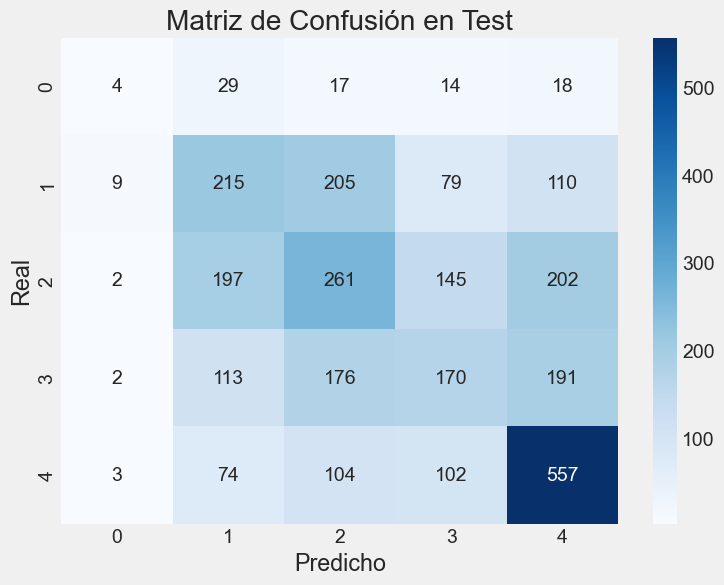

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Matriz de confusión para ver qué clases se confunden
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión en Test')
plt.show()